# Анализ перплексии распределения Qwen по n-граммам
Этот ноутбук вычисляет перплексию распределения вероятностей модели. для n-грамм разной длины и строит график зависимости.

In [ ]:
%pip install -q git+https://github.com/huggingface/transformers.git

In [ ]:
!pip install nltk

In [ ]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

## Загрузка модели и данных

In [ ]:
MODEL_NAME = "Qwen/Qwen3.5-0.8B-Base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Загрузка модели {MODEL_NAME} на {DEVICE}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto" if DEVICE == "cuda" else None,
    trust_remote_code=True
)
model.eval()

## Загружаем датасет

In [ ]:
print("Загрузка датасета...")
ds = load_dataset("gopalkalpande/bbc-news-summary")
texts = [item["Articles"] for item in ds["train"]]
texts = texts[:1000]
print(f"Всего текстов: {len(texts)}")

## Функции для извлечения n-грамм и вычисления распределения

In [ ]:
from tqdm.auto import tqdm

def extract_ngrams(texts, n):
    """
    Извлекает рандомные n подряд слов из каждого текста.
    """
    ngrams = []
    for text in texts:
        words = text.split()
        st = random.randint(0, max(
            0, len(words) - n + 1
        ))
        if len(words) >= n:
            ngrams.append(" ".join(words[st:st+n]))
    return ngrams

import string

import re
import string
from nltk.corpus import stopwords
import nltk

# Загружаем NLTK стоп-слова (один раз)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

# Расширенный набор: NLTK + пунктуация + цифры + спецтокены
STOP_WORDS = set(stopwords.words('english'))
STOP_WORDS.update(string.punctuation)
STOP_WORDS.update(str(i) for i in range(10))
STOP_WORDS.update(['', ' ', '  ', '<unk>', '<pad>', '</s>', '<s>', '[PAD]', '[UNK]', '``', "''"])

# Компилируем регулярку один раз
_TOKEN_CLEAN_RE = re.compile(r'^(Ġ|▁)+|##$')

def is_meaningful_token(token_str: str) -> bool:
    # Пропускаем пустые и только пробельные
    if not token_str or not token_str.strip():
        return False

    # Убираем лидирующий пробел (в Qwen новые слова начинаются с пробела)
    cleaned = token_str.lstrip(' ')

    # Пропускаем если после очистки пусто
    if not cleaned:
        return False

    # Пропускаем чистую пунктуацию и спецсимволы
    if all(c in string.punctuation + string.whitespace for c in cleaned):
        return False

    # Пропускаем слишком короткие «слова» (опционально)
    # Например, "a", "I" — можно оставить, а "ъ", "ь" — убрать
    if len(cleaned) < 2 and not cleaned.isalpha():
        return False

    # Пропускаем токены с управляющими символами
    if any(ord(c) < 32 and c not in ' \t\n\r' for c in token_str):
        return False

    # Только слова из букв (без цифр, дефисов и т.д.)
    if not cleaned.isalpha():
        return False

    # Только токены, начинающиеся с пробела (новые слова в Qwen)
    if not token_str.startswith(' '):
        return False

    if not token_str:
        return False

    # 1. Убираем артефакты токенизаторов
    cleaned = _TOKEN_CLEAN_RE.sub('', token_str).strip().lower()
    if not cleaned:
        return False

    # 2. Отсеиваем стоп-слова
    if cleaned in STOP_WORDS:
        return False

    # 3. Отсеиваем "мусор": одиночные не-буквы, чистые цифры, символы
    if len(cleaned) <= 1 and not cleaned.isalpha():
        return False

    return True


def compute_perplexity(probs, eps=1e-10):
    """
    Вычисляет перплексию распределения вероятностей.

    PPL = exp(entropy) = exp(-sum(p * log(p)))

    Args:
        probs: torch.Tensor с вероятностями (должны суммироваться в ~1)
        eps: малое число для численной стабильности

    Returns:
        float: перплексия
    """
    # Обрезаем вероятности для стабильности
    probs = torch.clamp(probs, min=eps)
    # Нормализуем (на случай накопленных ошибок)
    probs = probs / probs.sum()
    # Энтропия в натах
    entropy = -torch.sum(probs * torch.log(probs))
    # Перплексия
    perplexity = torch.exp(entropy)
    return perplexity.item()

In [ ]:
def get_mean_softmax_distribution(
    model,
    tokenizer,
    prompts,
    batch_size=32,
    filter_tokens=True,
    # --- Новый параметр: фильтр по уверенности (в духе LongPPL) ---
    confidence_threshold=None  # Если задано (напр. 0.2), игнорируем токены, где P_max < threshold
):
    """
    Вычисляет mean(softmax(logits)) распределение для списка промптов.

    Args:
        confidence_threshold: Если указано, пропускаем шаги, где модель "не уверена"
        (макс. вероятность токена ниже порога). Это аналог отбора "key tokens" из статьи,
        но без сложных вычислений LSD и второй модели.
    """
    vocab_size = model.lm_head.out_features
    device = model.device

    # 1. ПРЕДВЫЧИСЛЯЕМ МАСКУ ОСМЫСЛЕННЫХ ТОКЕНОВ (твоя базовая логика)
    if filter_tokens:
        print("  Precomputing meaningful token mask (one-time)...")
        meaningful_mask = torch.zeros(vocab_size, dtype=torch.bool, device=device)
        all_tokens = tokenizer.convert_ids_to_tokens(range(vocab_size))
        for i, token_str in enumerate(all_tokens):
            # Оставляем только те, что проходят твой фильтр
            if is_meaningful_token(tokenizer.decode([i], skip_special_tokens=True)):
                meaningful_mask[i] = True
    else:
        meaningful_mask = torch.ones(vocab_size, dtype=torch.bool, device=device)

    accumulated_probs = torch.zeros(vocab_size, device=device)
    total_processed = 0

    # 2. БАТЧИНГ ИНФЕРЕНСА
    for i in tqdm(range(0, len(prompts), batch_size)):
        batch_prompts = prompts[i:i+batch_size]
        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True).to(device)

        with torch.no_grad():
            logits = model(inputs.input_ids).logits

            # Индексы последнего реального токена
            last_token_idx = inputs.attention_mask.sum(dim=1) - 1
            batch_logits = logits[torch.arange(logits.size(0)), last_token_idx]

            probs = F.softmax(batch_logits, dim=-1)  # [batch, vocab]

            # 3. БАЗОВАЯ ФИЛЬТРАЦИЯ (твоя маска)
            probs = probs * meaningful_mask

            # 4. ПЕРЕНОРМАЛИЗАЦИЯ ПОСЛЕ БАЗОВОЙ ФИЛЬТРАЦИИ
            prob_sums = probs.sum(dim=1, keepdim=True)
            probs = probs / prob_sums.clamp(min=1e-9)

            # 5. НОВЫЙ ЭТАП: ОТБОР ПО УВЕРЕННОСТИ (LongPPL-style heuristic)
            if confidence_threshold is not None:
                # Если макс. вероятность (после фильтрации) ниже порога — модель "сомневается".
                # Такие примеры исключаем из усреднения, чтобы не размывать распределение.
                max_probs = probs.max(dim=-1).values
                confident_mask = (max_probs >= confidence_threshold)

                # Если в батче все токены "неуверенные", пропускаем итерацию
                if not confident_mask.any():
                    continue

                # Учитываем только уверенные предсказания
                probs = probs[confident_mask]
                batch_size_effective = confident_mask.sum().item()
            else:
                batch_size_effective = len(batch_prompts)

            accumulated_probs += probs.sum(dim=0)
            total_processed += batch_size_effective

    # Защита от деления на ноль, если всё отфильтровалось
    if total_processed == 0:
        print("Warning: All tokens were filtered out. Try lowering confidence_threshold.")
        return torch.zeros(vocab_size)

    mean_probs = accumulated_probs / total_processed
    return mean_probs.cpu()

## Основной цикл: вычисление перплексии для разных n

In [ ]:
import torch
torch.backends.cudnn.enabled = False  # Обход бага поиска движка для Conv1D

In [ ]:
MIN_N = 1
MAX_N = 20  # Максимальная длина n-граммы
results = {}

print("Вычисление перплексии для разных n...")

for n in range(MIN_N, MAX_N + 1):
    print(f"\n--- n={n} ---")

    # Извлекаем n-граммы
    ngrams = extract_ngrams(texts, n)
    print(f"  Найдено {len(ngrams)} n-грамм длины {n}")
    print(f"Пример n-граммы: {ngrams[0]}")

    if len(ngrams) == 0:
        print(f"  Пропускаем (нет данных)")
        continue

    # Вычисляем распределение модели
    print(f"  Вычисление распределения модели...")
    model_dist = get_mean_softmax_distribution(model, tokenizer, ngrams, confidence_threshold=0.2)

    # Считаем перплексию
    ppl = compute_perplexity(model_dist)
    results[n] = ppl

    print(f"  Перплексия: {ppl:.3f}")

    # Дополнительно: топ-10 токенов для анализа
    top_probs, top_indices = torch.topk(model_dist, k=10)
    top_tokens = [repr(tokenizer.decode([idx])) for idx in top_indices]
    print(f"  Топ-5 токенов: {list(zip(top_tokens[:5], top_probs[:5].numpy()))}")

Вычисление перплексии для разных n...

--- n=1 ---
  Найдено 1000 n-грамм длины 1
Пример n-граммы: corporation
  Вычисление распределения модели...
  Precomputing meaningful token mask (one-time)...


  0%|          | 0/32 [00:00<?, ?it/s]

  Перплексия: 822.884
  Топ-5 токенов: [("' known'", np.float32(0.11572223)), ("' want'", np.float32(0.030290186)), ("' True'", np.float32(0.028455056)), ("' us'", np.float32(0.022927621)), ("' need'", np.float32(0.022220306))]

--- n=2 ---
  Найдено 1000 n-грамм длины 2
Пример n-граммы: and introduce
  Вычисление распределения модели...
  Precomputing meaningful token mask (one-time)...


  0%|          | 0/32 [00:00<?, ?it/s]

  Перплексия: 1553.079
  Топ-5 токенов: [("' like'", np.float32(0.02613879)), ("' back'", np.float32(0.018442353)), ("' et'", np.float32(0.018413492)), ("' Henry'", np.float32(0.013224921)), ("' born'", np.float32(0.013138027))]

--- n=3 ---
  Найдено 1000 n-грамм длины 3
Пример n-граммы: not increased. Tax
  Вычисление распределения модели...
  Precomputing meaningful token mask (one-time)...


...

  Перплексия: 1591.677
  Топ-5 токенов: [("' said'", np.float32(0.017075196)), ("' last'", np.float32(0.015369325)), ("' would'", np.float32(0.013454092)), ("' back'", np.float32(0.011576877)), ("' year'", np.float32(0.011176704))]

--- n=29 ---
  Найдено 1000 n-грамм длины 29
Пример n-граммы: tax". The Tories say whatever the chancellor gives away will be clawed back in higher taxes if Labour is returned to power. Shadow Treasury chief secretary George Osborne said:
  Вычисление распределения модели...
  Precomputing meaningful token mask (one-time)...


  0%|          | 0/32 [00:00<?, ?it/s]

  Перплексия: 1499.823
  Топ-5 токенов: [("' would'", np.float32(0.01559416)), ("' said'", np.float32(0.013173109)), ("' back'", np.float32(0.011224549)), ("' one'", np.float32(0.009397195)), ("' could'", np.float32(0.0083398055))]

--- n=30 ---
  Найдено 1000 n-грамм длины 30
Пример n-граммы: we have set out to meet our spending commitments."..For the Lib Dems David Laws said: "The chancellor will no doubt tell us today how wonderfully the economy is doing," he
  Вычисление распределения модели...
  Precomputing meaningful token mask (one-time)...


  0%|          | 0/32 [00:00<?, ?it/s]

  Перплексия: 1522.999
  Топ-5 токенов: [("' said'", np.float32(0.026738761)), ("' would'", np.float32(0.01642549)), ("' back'", np.float32(0.011703392)), ("' last'", np.float32(0.009697205)), ("' time'", np.float32(0.009020706))]


## Визуализация результатов

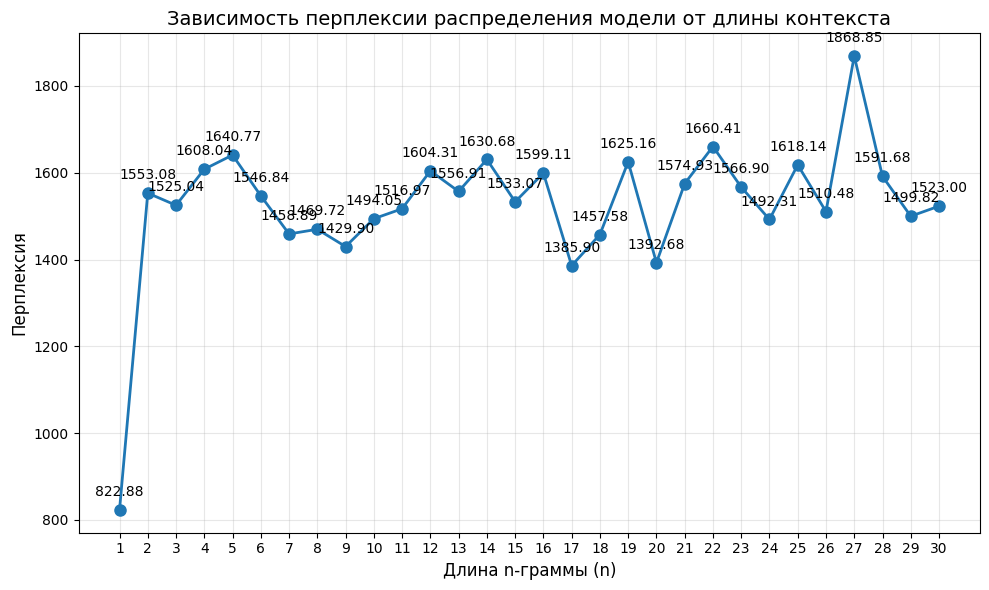

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(list(results.keys()), list(results.values()), marker='o', linewidth=2, markersize=8)
plt.xlabel('Длина n-граммы (n)', fontsize=12)
plt.ylabel('Перплексия', fontsize=12)
plt.title('Зависимость перплексии распределения модели от длины контекста', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(list(results.keys()))

# Добавляем значения на график
for n, ppl in results.items():
    plt.annotate(f'{ppl:.2f}', (n, ppl), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Таблица результатов

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'n': list(results.keys()),
    'Perplexity': [f"{ppl:.3f}" for ppl in results.values()],
    'Entropy (nats)': [f"{-np.log(ppl) if ppl > 0 else 0:.3f}" for ppl in results.values()]
})
print(df.to_string(index=False))

## Анализ: сравнение с равномерным распределением

In [ ]:
vocab_size = model.lm_head.out_features
uniform_ppl = vocab_size  # Перплексия равномерного распределения = размер словаря

print(f"\nРазмер словаря модели: {vocab_size:,}")
print(f"Перплексия равномерного распределения: {uniform_ppl:,.0f}")
print(f"\nОтношение перплексии модели к равномерной:")
for n, ppl in results.items():
    ratio = ppl / uniform_ppl * 100
    print(f"  n={n}: {ratio:.4f}% от равномерного")